# Exploration des résultats du pipeline Zenith

Ce notebook lit les sorties produites par `scripts/run_pipeline.py` et illustre :
1. La répartition ABC × XYZ
2. La détection d'obsolescence
3. Les performances de prévision par classe
4. La comparaison entre la politique empirique et la politique optimisée

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

clean = pd.read_parquet(ROOT / 'data/processed/transactions_clean.parquet')
products = pd.read_csv(ROOT / 'data/results/obsolescence.csv')
metrics = pd.read_csv(ROOT / 'data/results/forecast_metrics.csv')
metrics_by_class = pd.read_csv(ROOT / 'data/results/forecast_metrics_by_class.csv')
plan = pd.read_csv(ROOT / 'data/results/optimization_plan.csv')
compare = pd.read_csv(ROOT / 'data/results/financial_comparison.csv')

print(f'Transactions nettoyées : {len(clean):,}'.replace(',', ' '))
print(f'Produits : {len(products)}')
print(f'Période : {clean.date.min().date()} → {clean.date.max().date()}')

Transactions nettoyées : 66 915
Produits : 250
Période : 2022-08-01 → 2025-07-31


## 1. Classification ABC × XYZ

In [2]:
products.groupby(['classe_abc','classe_xyz']).size().unstack(fill_value=0)

classe_xyz,X,Y,Z
classe_abc,,,
A,20,46,3
B,25,29,5
C,54,50,18


## 2. Détection d'obsolescence

In [3]:
products['a_risque_obsolescence'].value_counts(normalize=True).rename({0:'actif', 1:'à risque'})

a_risque_obsolescence
actif       0.708
à risque    0.292
Name: proportion, dtype: float64

In [4]:
products[products.a_risque_obsolescence==1][['produit_id','famille','classe_abc','jours_depuis_derniere_vente','ratio_ventes_3m_vs_12m']].head(15)

,produit_id,famille,classe_abc,jours_depuis_derniere_vente,ratio_ventes_3m_vs_12m
3,P0021,Cartouche,A,1,0.041379
8,P0020,Cartouche,A,348,0.000000
9,P0017,Cartouche,A,306,0.000000
16,P0073,Ordinateur,A,128,0.000000
27,P0069,Ordinateur,A,313,0.000000
30,P0068,Ordinateur,A,0,0.099099
32,P0004,Cartouche,A,233,0.000000
33,P0013,Cartouche,A,685,0.000000
34,P0012,Cartouche,A,679,0.000000
35,P0008,Cartouche,A,5,0.523077


## 3. Précision des modèles de prévision (par classe ABC)

In [5]:
metrics_by_class

,classe_abc,modele,n_produits,mae_moy,rmse_moy,mape_moy
0,A,croston,2,12.819,13.886,332.365
1,A,lstm,48,7.234,8.378,126.464
2,A,obsolete,19,NaN,NaN,NaN
3,B,lightgbm,39,7.754,9.143,75.447
4,B,obsolete,20,NaN,NaN,NaN
5,C,croston,7,4.368,5.248,165.716
6,C,obsolete,34,NaN,NaN,NaN
7,C,sarima,81,15.725,18.594,116.956


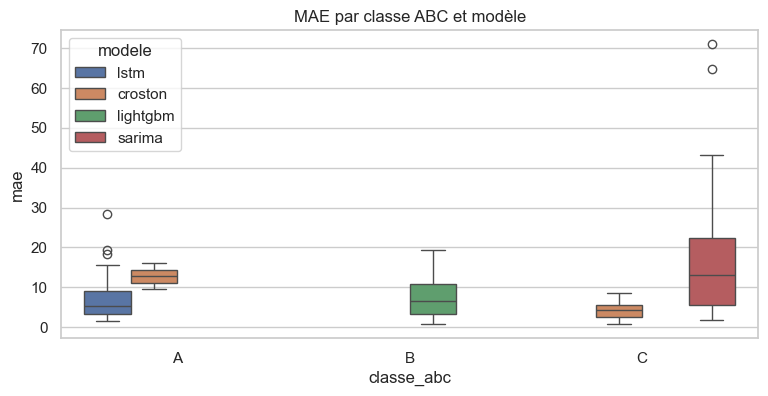

In [6]:
fig, ax = plt.subplots(figsize=(9,4))
sns.boxplot(data=metrics.dropna(subset=['mae']), x='classe_abc', y='mae', hue='modele', order=['A','B','C'], ax=ax)
ax.set_title('MAE par classe ABC et modèle')
plt.show()

## 4. Politique empirique vs politique optimisée

In [7]:
compare

,indicateur,politique_empirique,politique_optimisee,delta,delta_pct
0,nb_commandes,501.00,696.00,195.00,38.92
1,qte_commandee_totale,24433.00,15749.00,-8684.00,-35.54
2,valeur_commande_totale,1661989.20,1176344.25,-485644.95,-29.22
3,stock_moyen_immo_usd,1295.47,134.44,-1161.03,-89.62
4,nb_ruptures_unites,4427.51,4234.97,-192.54,-4.35
5,marge_perdue_usd,40618.18,37050.09,-3568.09,-8.78
6,cout_commande_total_usd,25050.00,34800.00,9750.00,38.92
7,cout_stockage_total_usd,58295.94,4283.13,-54012.81,-92.65
8,cout_total_simule_usd,123964.11,76133.21,-47830.90,-38.58
9,ca_realise_usd,1802645.15,1821351.14,18705.98,1.04


In [8]:
agg = plan.groupby('classe_abc').agg(
    demande=('demande_prevue','sum'),
    qte=('quantite_commandee','sum'),
    rupture=('rupture','sum'),
)
agg['taux_service'] = (1 - agg['rupture'] / agg['demande']) * 100
agg.round(1)

,demande,qte,rupture,taux_service
classe_abc,,,,
A,4449.0,3357,358.0,92.0
B,4774.6,3153,916.2,80.8
C,15214.3,9239,2960.7,80.5
